create a chatbot to respond the query on basis of sentiment of user query.

In [1]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
from typing import TypedDict,Literal
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI 

In [2]:
load_dotenv()
model=ChatOpenAI(model='gpt-4o-mini')

In [3]:
#to get the sentiment of the text (positive/negative ), it means structured output 
class SentimentSchema(BaseModel):
    sentiment:Literal['Positive','Negative'] = Field(description="sentiment of the review")

class DiagnosisSchema(BaseModel):
    issue_type:Literal['UX','Performance','Bug','Support','other'] = Field(description="Issue type")
    tone:Literal["Angry","Frustated","Disappointed","Calm"] = Field(description="Tone of message")
    urgency:Literal["Low","Medium","High"]

str_model=model.with_structured_output(schema=SentimentSchema)

diagnose_model=model.with_structured_output(schema=DiagnosisSchema)

In [4]:
class ReviewState(TypedDict):
    text:str
    sentiment:Literal["Positive","Negative"]
    diagnosis:dict
    response:str
    

In [5]:
def sentiment_review(state:ReviewState)->Literal['Positive','Negative']:
    prompt=f"find the sentiment of the text:{state['text']}"
    sentiment=str_model.invoke(prompt).sentiment
    return {'sentiment':sentiment}

def positive_response(state:ReviewState):
    prompt=f"write the warm thankyou message and ask to write a review:{state['text']}"
    out=model.invoke(prompt).content
    return {'response':out}

def run_diagnosis(state:ReviewState):
    prompt=f"run the diagnosis on negative setiment messages :{state['text']} and return issue_type, tone and urgency"
    out=diagnose_model.invoke(prompt)
    return {'diagnosis':out.model_dump()}
    #model_dump converts the pydantic to dictionary

def negative_response(state:ReviewState):
    prompt=f"""you are a support agent  and the user had issue with {state['diagnosis']['issue_type']},
    ,tone was {state['diagnosis']['tone']} and urgeny was {state['diagnosis']['urgency']} 
    """
    out=model.invoke(prompt).content
    return {'response':out}

def check_sentiment(state:ReviewState):
    if state['sentiment']=='Positive':
        return 'positive_response'
    else :
        return 'run_diagnosis'

In [6]:
graph=StateGraph(ReviewState)
# add a nodes
graph.add_node("sentiment_review",sentiment_review)
graph.add_node("positive_response",positive_response)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)

# add a edges
graph.add_edge(START,"sentiment_review")
graph.add_conditional_edges("sentiment_review",check_sentiment,{ "positive_response": "positive_response", "run_diagnosis": "run_diagnosis" })
graph.add_edge('run_diagnosis',"negative_response")
graph.add_edge("positive_response",END)
graph.add_edge("negative_response",END)

workflow=graph.compile()


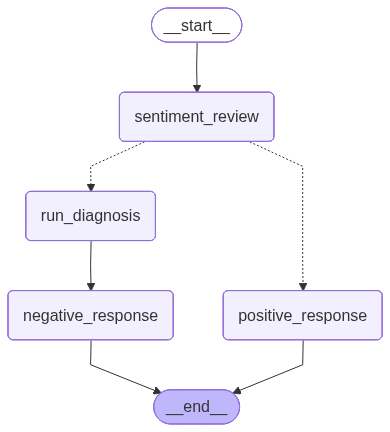

In [7]:
workflow

In [9]:
intial_state={
    'text': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)


{'text': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'Negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'Frustated', 'urgency': 'High'},
 'response': 'Hi there! I’m really sorry to hear that you’re experiencing issues with the bug. I completely understand how frustrating this must be for you, especially when it’s urgent. I’m here to help you resolve this as quickly as possible.\n\nCould you please provide me with more details about the bug you’re encountering? Any specific error messages or behaviors you’re seeing will be really helpful in diagnosing the problem. Thank you!'}